# Mersenne Prime Cryptosystem

## Introduction

### 1. Mathematical Definitions

### Mersenne Numbers
A Mersenne number $M_n$ is defined by the following expression:
$$M_n = 2^n - 1$$
where $n$ is a positive integer.

* **Mersenne Prime:** A Mersenne number $M_n$ is considered a *Mersenne Prime* if the resulting value is a prime number.

### Hamming Weight
The Hamming Weight of an $n$-bit string $y$, denoted by $\text{Ham}(y)$, represents the total count of '1's in the string.

---

### 2. Complement Property
For any value $A$ (where $A \neq 0^n$), the relationship between the weight of a number and its negative (in two's complement) is given by:

$$\text{Ham}(-A) = n - \text{Ham}(A)$$



## Bit by Bit encryption

### Encrypt a single bit

In [ ]:
import math
import secrets
from scipy.special import comb

def low_hamming_weight_number(n, h):
    """Gera um número de n bits com peso de Hamming h."""
    indices = set()
    while len(indices) < h:
        indices.add(secrets.randbelow(n))
    num = 0
    for i in indices:
        num |= (1 << i)
    return num

def hamming_weight(x):
    """Calcula o Peso de Hamming (quantidade de bits '1')"""
    return bin(x).count('1')

def get_n_h(lambda_param):
    """
    Finds valid n and h such that comb(n, h) >= 2^lambda
    and 4h^2 < n < 16h^2.
    """
    # Start with a reasonable n based on lambda, e.g., n approx 2*lambda
    n = int(lambda_param * 2) 
    while True:
        # Based on 4h^2 < n < 16h^2:
        # h > sqrt(n/16) and h < sqrt(n/4)
        h_min = math.floor(math.sqrt(n / 16)) + 1
        h_max = math.ceil(math.sqrt(n / 4)) - 1
        
        for h in range(h_min, h_max + 1):
            if comb(n, h, exact=True) >= 2**lambda_param:
                return n, h
        n += 1 # Increase n if no h is found for current n

# Your validated list of Mersenne exponents
MERSENNE_EXPONENTS = [
    2, 3, 5, 7, 13, 17, 19, 31, 61, 89, 107, 127, 521, 607, 1279, 2203, 
    2281, 3217, 4253, 4423, 9689, 9941, 11213, 19937, 21701, 23209, 44497, 
    86243, 110503, 132049, 216091, 756839, 859433, 1257787, 1398269, 
    2976221, 3021377, 6972593, 13466917, 20996011, 24036583, 25964951, 
    30402457, 32582657, 37156667, 42643801, 43112609, 57885161, 74207281, 
    77232917, 82589933, 136279841
]

def get_n_h_from_list(lambda_param):
    """
    Finds n from MERSENNE_EXPONENTS and h such that comb(n, h) >= 2^lambda
    and 4h^2 < n < 16h^2.
    """
    for n in MERSENNE_EXPONENTS:
        # Constraints: h > sqrt(n/16) and h < sqrt(n/4)
        h_min = math.floor(math.sqrt(n / 16)) + 1
        h_max = math.ceil(math.sqrt(n / 4)) - 1
        
        for h in range(h_min, h_max + 1):
            if comb(n, h, exact=True) >= 2**lambda_param:
                return n, h
    raise ValueError("No suitable n and h found for the given lambda.")

def generate_keys(lambda_param):
    # Retrieve n from our list and calculate corresponding h
    n, h = get_n_h_from_list(lambda_param)
    p = (2**n) - 1
    
    #generate F and G until G is invertible mod p and F, G have low Hamming weight (h)
    while True:
        F = low_hamming_weight_number(n, h)
        G = low_hamming_weight_number(n, h)
        
        try:
            # H = F * G^-1 (mod p)
            inv_G = pow(G, -1, p)
            H = (F * inv_G) % p
            return (H, G, n, h, p)
        except ValueError:
            continue # G is not invertible, try again

def encrypt(pk_H, b, n, p, h):
    """
    C = (-1)^b * (A * H + B) mod p
    """
    #Generate A and B with low Hamming weight (h)
    A = low_hamming_weight_number(n, h)
    B = low_hamming_weight_number(n, h)
    
    val = (A * pk_H + B) % p
    
    if b == 0:
        return val
    else:
        # (-1) * val no mundo modular é p - val
        return (p - val) % p

def decrypt(C, sk_G, n, p, h):
    """
    Computes d=Ham(C * G mod p) and decides based on d.
    If d <= 2h^2, output 0; if d >= n - 2h^2, output 1; else output "?".
    """
    # d = Ham(C * G mod p)
    target = (C * sk_G) % p
    d = hamming_weight(target)
    
    threshold = 2 * (h**2)
    
    if d <= threshold:
        return 0
    elif d >= n - threshold:
        return 1
    else:
        return None # Caso "?" (Indeterminado)

# --- Exemplo de Execução ---

# 1. Parâmetros (p deve ser um primo de Mersenne)
lambda_param= 256

# 2. Setup de Chaves
pk, sk, n, h, p  = generate_keys(256)

# 3. Teste com bit 0
bit_original = 1
criptograma = encrypt(pk, bit_original, n, p, h)
bit_recuperado = decrypt(criptograma, sk, n, p, h)

print(f"Parâmetros: n={n}, h={h_usado}")
print(f"Bit Original: {bit_original}")
print(f"Criptograma (C): {hex(criptograma)[:20]}...")
print(f"Bit Recuperado: {bit_recuperado}")

Parâmetros: n=4253, h=31
Bit Original: 1
Criptograma (C): 0x1e8eeea9f109261361...
Bit Recuperado: 1


### Encrypt a message

In [9]:

def iterar(m, pk, n, p, h):
    """Encripta uma mensagem (inteiro) bit a bit."""
    mens = bin(m)[2:]
    # Usamos as funções já definidas: encrypt(pk_H, b, n, p, h)
    lista_cripto = [encrypt(pk, int(bit), n, p, h) for bit in mens]
    return lista_cripto

def iterar_descriptar(criptograma, G, n, p, h):
    """Descripta uma lista de criptogramas bit a bit."""
    # Usamos a função já definida: decrypt(C, sk_G, n, p, h)
    resultado = [decrypt(c, G, n, p, h) for c in criptograma]
    return resultado

# --- Exemplo de Execução ---

# --- Configuração Inicial ---
lambda_param = 256
pk, sk, n, h, p = generate_keys(lambda_param)


# 1. Definir a mensagem (em binário)
mensagem_str = "1101101010110101011001010101011100001011011011"
mensagem = int(mensagem_str, 2)

print(f"Mensagem original: {mensagem_str}")
print(f"Parâmetros: n={n}, h={h}")

# 2. Encriptar
lista_encriptada = iterar(mensagem, pk, n, p, h)
print(f"Criptograma gerado (primeiros 5 elementos): {lista_encriptada[:5]}...")

# 3. Descriptar
resultado = iterar_descriptar(lista_encriptada, sk, n, p, h)

# 4. Resultado final
# Filtramos os 'None' caso algum bit tenha sido indeterminado
mensagem_recuperada = ''.join(map(str, [x for x in resultado if x is not None]))
print(f"Mensagem recuperada: {mensagem_recuperada}")

# Verificação de sucesso
if mensagem_str == mensagem_recuperada:
    print("\nSucesso: A mensagem foi recuperada corretamente!")
else:
    print("\nErro: A mensagem recuperada difere da original.")

Mensagem original: 1101101010110101011001010101011100001011011011
Parâmetros: n=4253, h=31
Criptograma gerado (primeiros 5 elementos): [693943266560081595847409775703521630800911223080337988276728864527714002708685564653807835358490094455939413136313046523783927461566581417057858780019034990033793459779374894788235344040688886310472788508138811954493251074194867777527786316570269710676332483626056597201434674047025710665981092308744772393082579262427927989708163478161512149812266089477191765608115145415325274315506435609898088709992782015759854390482395183103326930722004614900393059942172146544426050881596036563383488664684446209611685642025059442167906210591466579884363516840879610020475332752604980155554553068421482098282940723745932267483887185163951960701800426150799647352195303539693988872166434873006850487602645383899662221192325945007148119656333999516476886716156962060670812832241265568873104635422528594437534915722574642704275250692927606465978883067561504249429461905914621024

### Attacking this encryption scheme

In [97]:
# 

def generate_WEAK_keys_for_attack(n, h, p):
    """The generated keys F and G will have bits only in the lower half to test the attack."""
    limite_bits = n // 2
    
    while True:
        # F e G com bits apenas na metade inferior (fator de redução da chave)
        F = low_hamming_weight_number(n, h) & ((1 << limite_bits) - 1)
        G = low_hamming_weight_number(n, h) & ((1 << limite_bits) - 1)
        
        if G == 0: continue
        try:
            inv_G = pow(G, -1, p)
            H = (F * inv_G) % p
            return (H, G, F, h)
        except ValueError:
            continue

def run_attack(H, p, F_secreto, sk_G):
    from sympy import Rational, continued_fraction_iterator, continued_fraction_convergents
    
    convergentes_encontrados = []
    fração_exata = Rational(H, p)
    cf = continued_fraction_iterator(fração_exata)
    
    # O ataque percorre os convergentes da fração contínua de H/p
    for conv in continued_fraction_convergents(cf):
        cand_G = int(conv.q)
        if cand_G == 0: continue
            
        cand_F = (H * cand_G) % p
        
        # Testar o par encontrado
        if cand_F == F_secreto and cand_G == sk_G:
            return cand_F, cand_G
            
    return None, None


# --- [1] CONFIGURAÇÃO E SETUP ---
lambda_param = 10 #Security parameter
n, h = get_n_h_from_list(lambda_param)
p = (2**n) - 1

print(f"--- [1] SETUP DO SISTEMA (lambda={lambda_param}) ---")
print(f"Parâmetros selecionados: n={n}, h={h}")

pk_H, sk_G, F_secreto, _ = generate_WEAK_keys_for_attack(n, h, p)

print(f"Chave Secreta G: {hex(sk_G)}")
print(f"Chave Pública H: {hex(pk_H)[:30]}...")

# --- [2] Starting Continuous Fractions Attack ---
print("\n--- [2] Starting Continuous Fractions Attack ---")

count=0
while count<500:
    F_atk, G_atk = run_attack(pk_H, p, F_secreto, sk_G)

    if F_atk:
        print(f"\n[✓] ATAQUE BEM-SUCEDIDO!")
        print(f"F recuperado: {hex(F_atk)}")
        print(f"G recuperado: {hex(G_atk)}")
        print(f"Iteração {count+1} concluída.")
        break
    else:
        count += 1


--- [1] SETUP DO SISTEMA (lambda=10) ---
Parâmetros selecionados: n=61, h=2
Chave Secreta G: 0x1
Chave Pública H: 0x800000...

--- [2] Starting Continuous Fractions Attack ---

[✓] ATAQUE BEM-SUCEDIDO!
F recuperado: 0x800000
G recuperado: 0x1
Iteração 1 concluída.


## Secure Public Key Cruptosystem

### With Repetition Code

#### Choosing distance code given n and size of the message

In [9]:
import secrets
import math

def low_hamming_weight_number(n, h):
    """Gera uma string de n bits com peso de Hamming exatamente h."""
    indices = set()
    while len(indices) < h:
        indices.add(secrets.randbelow(n))
    num = 0
    for i in indices:
        num |= (1 << i)
    return num

def repetition_encode(m_bits, k, n):
    """Repetition Code E(m): Repeat each bit of m_bits rep times, where rep = n // k."""
    rep = n // k
    encoded = 0
    for i in range(k):
        bit = (m_bits >> i) & 1
        if bit:
            mask = ((1 << rep) - 1) << (i * rep)
            encoded |= mask
    return encoded

def repetition_decode(c_star, k, n):
    """D(C*): Decodificação por votação majoritária."""
    rep = n // k
    decoded = 0
    for i in range(k):
        block = (c_star >> (i * rep)) & ((1 << rep) - 1)
        if bin(block).count('1') > (rep // 2):
            decoded |= (1 << i)
    return decoded

# Your validated list of Mersenne exponents
MERSENNE_EXPONENTS = [
    2, 3, 5, 7, 13, 17, 19, 31, 61, 89, 107, 127, 521, 607, 1279, 2203, 
    2281, 3217, 4253, 4423, 9689, 9941, 11213, 19937, 21701, 23209, 44497, 
    86243, 110503, 132049, 216091, 756839, 859433, 1257787, 1398269, 
    2976221, 3021377, 6972593, 13466917, 20996011, 24036583, 25964951, 
    30402457, 32582657, 37156667, 42643801, 43112609, 57885161, 74207281, 
    77232917, 82589933, 136279841
]

def get_mersenne_exponent(h):
    """
    Finds the smallest Mersenne exponent n such that n > 10 * h^2.
    """
    
    n_min = 10 * (h**2)
    n_max= 16 * (h**2)
    
    for n in MERSENNE_EXPONENTS:
        if n >= n_min and n <= n_max:
            return n

    return n_min 

def generate_keys(lambda_param):
    """
    Key Generation based on Mersenne Prime n.
    h = lambda
    n is a Mersenne exponent such that n > 10h^2
    """
    h = lambda_param
    
    # 1. Select a valid Mersenne exponent n
    n = get_mersenne_exponent(h)
    
    # 2. Define the Mersenne Prime p = 2^n - 1
    p = (1 << n) - 1
    
    # 3. Generate low Hamming weight elements
    F = low_hamming_weight_number(n, h)
    G = low_hamming_weight_number(n, h)
    R = secrets.randbits(n)
    
    # 4. pk := (R, T) where T = (F * R + G) mod p
    T = (F * R + G) % p
    
    return (R, T), F, n, p, h

def encrypt(pk, m, n, p, h, k):
    """
    Enc(pk, m) := (C1, C2)
    C1 = A * R + B1
    C2 = (A * T + B2) XOR E(m)
    """
    R, T = pk
    A = low_hamming_weight_number(n, h)
    B1 = low_hamming_weight_number(n, h)
    B2 = low_hamming_weight_number(n, h)
    
    # E(m)
    encoded_m = repetition_encode(m, k, n)
    
    C1 = (A * R + B1) % p
    pad = (A * T + B2) % p
    C2 = pad ^ encoded_m
    
    return (C1, C2)

def decrypt(C, sk_F, n, p, h, k):
    """
    Dec(sk, C) := D((F * C1) XOR C2)
    """
    C1, C2 = C
    
    # Calcula o termo que deve cancelar o pad: F * C1
    # F * (A * R + B1) = A * F * R + F * B1
    f_c1 = (sk_F * C1) % p
    
    # Extrai a mensagem com ruído usando XOR
    noisy_m = f_c1 ^ C2
    
    # D(noisy_m)
    return repetition_decode(noisy_m, k, n)

# --- Execução ---
lambda_sec = 256  # = size of the message in bits

# 1. Setup
pk, sk, n, p, h = generate_keys(lambda_sec)

print(f"n: {n}")
k=lambda_sec
print(f"distance of the repetition code: {n//k}")

# 2. Mensagem m (Ex: 16 bits aleatórios)
m_original = secrets.randbits(lambda_sec)

# 3. Cifrar
C = encrypt(pk, m_original, n, p, h, k)

# 4. Decifrar
m_recuperada = decrypt(C, sk, n, p, h, k)

print(f"--- Sistema de Bloco (Mersenne) ---")
print(f"n: {n}, h: {h}, lambda: {lambda_sec}")
print(f"Mensagem Original:  {bin(m_original)}")
print(f"Mensagem Recuperada: {bin(m_recuperada)}")
print(f"Sucesso: {m_original == m_recuperada}")

n: 756839
distance of the repetition code: 2956
--- Sistema de Bloco (Mersenne) ---
n: 756839, h: 256, lambda: 256
Mensagem Original:  0b100110100100110111110110011000100101011001111000010110010011010101011100011100111110010011010001110110111011100111000001001110111010111010110110011011011011110110001111111011010101000010001011101000100010100101100111000010111100100111101111100011110
Mensagem Recuperada: 0b100110100100110111110110011000100101011001111000010110010011010101011100011100111110010011010001110110111011100111000001001110111010111010110110011011011011110110001111111011010101000010001011101000100010100101100111000010111100100111101111100011110
Sucesso: True


#### Given the distance of the code

In [11]:
import secrets

def repetition_encode_given_rep(m_bits, rep):
    """
    Repetition Code E(m): Repeat each bit of m_bits 'rep' times.
    """

    encoded = 0
    for i in range(len(bin(m_bits)) - 2):  # Iterate over each bit of m_bits
        bit = (m_bits >> i) & 1
        if bit:
            # Create a block of 'rep' ones and shift to the correct position
            mask = ((1 << rep) - 1) << (i * rep)
            encoded |= mask
    return encoded

def repetition_decode_given_rep(c_star, rep):
    """
    D(C*): Decodificação por votação majoritária com 'rep' definido.
    """
    decoded = 0
    for i in range(len(bin(c_star)) - 2):  # Iterate over each bit of c_star
        # Extract the specific block of 'rep' bits
        block = (c_star >> (i * rep)) & ((1 << rep) - 1)
        # Majority vote: count bits and compare to half the repetition length
        if bin(block).count('1') > (rep // 2):
            decoded |= (1 << i)
    return decoded


def encrypt_given_rep(pk, m, n, p, h, rep):
    """
    Enc(pk, m) := (C1, C2)
    C1 = A * R + B1
    C2 = (A * T + B2) XOR E(m)
    """

    # Validation check
    if (rep_factor * lambda_sec) > n:
        raise ValueError(f"Total encoded size ({rep_factor * lambda_sec}) exceeds n ({n}).")
    
    R, T = pk
    A = low_hamming_weight_number(n, h)
    B1 = low_hamming_weight_number(n, h)
    B2 = low_hamming_weight_number(n, h)
    
    # E(m)
    encoded_m = repetition_encode_given_rep(m, rep)
    
    C1 = (A * R + B1) % p
    pad = (A * T + B2) % p
    C2 = pad ^ encoded_m
    
    return (C1, C2)

def decrypt_given_rep(C, sk_F, n, p, h, rep):
    """
    Dec(sk, C) := D((F * C1) XOR C2)
    """

    # Validation check
    if (rep_factor * lambda_sec) > n:
        raise ValueError(f"Total encoded size ({rep_factor * lambda_sec}) exceeds n ({n}).")
    

    C1, C2 = C
    
    # Calcula o termo que deve cancelar o pad: F * C1
    # F * (A * R + B1) = A * F * R + F * B1
    f_c1 = (sk_F * C1) % p
    
    # Extrai a mensagem com ruído usando XOR
    noisy_m = f_c1 ^ C2
    
    # D(noisy_m)
    return repetition_decode_given_rep(noisy_m, rep)

# --- Updated Execution Flow ---

lambda_sec = 256  # Size of the message in bits
rep_factor = 2058    # User-defined repetition factor

# 1. Setup
pk, sk, n, p, h = generate_keys(lambda_sec)

# 1. Mensagem original
m_original = secrets.randbits(lambda_sec)

# 3. Cifrar
C = encrypt_given_rep(pk, m_original, n, p, h, rep_factor)

# 4. Decifrar
m_recuperada = decrypt_given_rep(C, sk, n, p, h, rep_factor)

print(f"--- Sistema de Bloco (Mersenne) ---")
print(f"n: {n}, h: {h}, lambda: {lambda_sec}")
print(f"Mensagem Original:  {bin(m_original)}")
print(f"Mensagem Recuperada: {bin(m_recuperada)}")
print(f"Sucesso: {m_original == m_recuperada}")

--- Sistema de Bloco (Mersenne) ---
n: 756839, h: 256, lambda: 256
Mensagem Original:  0b1011010100000001000001000111100000010100100110111011110100001000110110100111111111001000000101110001110101000100110110010001011000011001010110101110111000001001100101111001111001110011100001011010110110110110101110010000001000001011100101110111000101010111
Mensagem Recuperada: 0b1011010100000001000001000111100000010100100110111011110100001000110110100111111111001000000101110001110101000100110110010001011000011001010110101110111000001001100101111001111001110011100001011010110110110110101110010000001000001011100101110111000101010111
Sucesso: True


### With ReedMuller Code

#### Functions ReedMuller

In [2]:
from itertools import combinations, product
import numpy as np

from itertools import combinations, product
import numpy as np

def get_points(m):
    """
    Gera pontos com x_{m-1} variando mais lentamente:
    Primeiros 2^(m-1) pontos têm x_{m-1}=0
    Últimos    2^(m-1) pontos têm x_{m-1}=1
    """
    if m == 0:
        return [()]
    sub = get_points(m-1)
    # x_{m-1}=0 primeiro, x_{m-1}=1 depois
    return [p + (0,) for p in sub] + [p + (1,) for p in sub]


def get_monomials(m, r):
    if m == 0:
        return [[]]
    without_xm = get_monomials(m-1, r)
    if r >= 1:
        with_xm_base = get_monomials(m-1, r-1)
        with_xm = [mono + [m-1] for mono in with_xm_base]
    else:
        with_xm = []
    return without_xm + with_xm


def generator_matrix(m, r):
    points = get_points(m)  # ← usa a nova ordem!
    n = 2**m
    monomials = get_monomials(m, r)
    k = len(monomials)
    G = np.zeros((k, n), dtype=int)
    for i, mono in enumerate(monomials):
        for j, point in enumerate(points):
            val = 1
            for idx in mono:
                val *= point[idx]
            G[i][j] = val % 2
    return G, monomials


def encode(message, G):
    return np.dot(message, G) % 2


def inverse_mod2(M):
    n = M.shape[0]
    A = np.concatenate([M.copy(), np.eye(n, dtype=int)], axis=1) % 2
    for i in range(n):
        if A[i,i] == 0:
            for j in range(i+1, n):
                if A[j,i] == 1:
                    A[[i,j]] = A[[j,i]]
                    break
        for j in range(n):
            if j != i and A[j,i] == 1:
                A[j] = (A[j] + A[i]) % 2
    return A[:, n:]


def decode_recursive(received, m, r, G_inv_cache=None):
    if G_inv_cache is None:
        G_inv_cache = {}
    n = 2**m

    if r == m:
        if (m, r) not in G_inv_cache:
            G, _ = generator_matrix(m, r)
            G_inv_cache[(m, r)] = inverse_mod2(G)
        G_inv = G_inv_cache[(m, r)]
        return (np.dot(received, G_inv) % 2).tolist()

    if r == 0:
        bit = 1 if sum(received) > len(received)/2 else 0
        return [bit]

    half = n // 2
    u   = received[:half]
    upv = received[half:]
    v = [u[i] ^ upv[i] for i in range(half)]

    coefs_h = decode_recursive(v, m-1, r-1, G_inv_cache)
    coefs_g = decode_recursive(list(u), m-1, r, G_inv_cache)

    return coefs_g + coefs_h

In [7]:
# ===== TESTE RM(4,3) =====

m, r = 22, 1

G, monomials = generator_matrix(m, r)
k = len(monomials)

# Gera mensagem aleatória do tamanho correcto
mensagem = np.random.randint(0, 2, size=k)

print(f"RM({m},{r}): n={2**m}, k={len(monomials)}, d={2**(m-r)}")
print()

codeword = encode(mensagem, G)

print(f"Mensagem:   {mensagem.tolist()}")
#print(f"Codeword:   {codeword.tolist()}")

# Introduz 1 erro
recebido = codeword.copy()
recebido[11] ^=1
recebido[21] ^=1
recebido[9] ^=1
#print(f"Recebido:   {recebido.tolist()}  (erro na posição 5)")

recuperado = decode_recursive(recebido.tolist(), m, r)
print(f"Recuperado: {recuperado}")
print(f"Correcto:   {recuperado == mensagem.tolist()}")

RM(22,1): n=4194304, k=23, d=2097152

Mensagem:   [0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0]
Recuperado: [0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0]
Correcto:   True


#### Encrypt using ReedMuller

## Mersenne Key Encapsulation Mechanism

### Encapsulation Method with repetition code

#### Choosing distance code given n and size of the message

In [22]:
import secrets
import math
import hashlib

def low_hamming_weight_number(n, h):
    indices = set()
    while len(indices) < h:
        indices.add(secrets.randbelow(n))
    num = 0
    for i in indices:
        num |= (1 << i)
    return num

def repetition_encode(m_bits, k, n):
    rep = n // k
    encoded = 0
    for i in range(k):
        bit = (m_bits >> i) & 1
        if bit:
            mask = ((1 << rep) - 1) << (i * rep)
            encoded |= mask
    return encoded

def repetition_decode(c_star, k, n):
    rep = n // k
    decoded = 0
    for i in range(k):
        block = (c_star >> (i * rep)) & ((1 << rep) - 1)
        if bin(block).count('1') > (rep // 2):
            decoded |= (1 << i)
    return decoded

# Your validated list of Mersenne exponents
MERSENNE_EXPONENTS = [
    2, 3, 5, 7, 13, 17, 19, 31, 61, 89, 107, 127, 521, 607, 1279, 2203, 
    2281, 3217, 4253, 4423, 9689, 9941, 11213, 19937, 21701, 23209, 44497, 
    86243, 110503, 132049, 216091, 756839, 859433, 1257787, 1398269, 
    2976221, 3021377, 6972593, 13466917, 20996011, 24036583, 25964951, 
    30402457, 32582657, 37156667, 42643801, 43112609, 57885161, 74207281, 
    77232917, 82589933, 136279841
]

def get_mersenne_exponent(h):
    """
    Finds the smallest Mersenne exponent n such that n > 10 * h^2.
    """
    
    n_min = 10 * (h**2)
    n_max= 16 * (h**2)
    
    for n in MERSENNE_EXPONENTS:
        if n >= n_min and n <= n_max:
            return n

    return n_min 

# --- Oráculos Aleatórios (Expandable Hash) ---

def expandable_hash_to_hamming(seed_int, n, h, lambda_param, salt=b''):
    # Converte o inteiro K para bytes para o Hash
    seed_bytes = seed_int.to_bytes((lambda_param + 7) // 8, 'big')
    xo_function = hashlib.shake_256(seed_bytes + salt)
    
    indices = set()
    byte_counter = 0
    while len(indices) < h:
        bytes_needed = (n.bit_length() + 7) // 8
        raw_bytes = xo_function.digest(byte_counter + bytes_needed)[byte_counter:]
        idx = int.from_bytes(raw_bytes, 'big') % n
        indices.add(idx)
        byte_counter += bytes_needed
        
    num = 0
    for i in indices:
        num |= (1 << i)
    return num

def H1(K, n, h, lp): return expandable_hash_to_hamming(K, n, h, lp, b'H1')
def H2(K, n, h, lp): return expandable_hash_to_hamming(K, n, h, lp, b'H2')
def H3(K, n, h, lp): return expandable_hash_to_hamming(K, n, h, lp, b'H3')

# --- Core: Geração, Encapsulamento e Decapsulamento ---

def generate_keys(lambda_sec):
    h = lambda_sec
    n = get_mersenne_exponent(h)
    p = (1 << n) - 1
    F = low_hamming_weight_number(n, h)
    G = low_hamming_weight_number(n, h)
    R = secrets.randbits(n)
    T = (F * R + G) % p
    return (R, T), F, n, p, h

def key_encapsulation(pk, lambda_param, n, p, h):
    # 1. Pick a uniformly random lambda-bit string K
    K = secrets.randbits(lambda_param)

    # 2. Let A = H1(K), B1 = H2(K), and B2 = H3(K)
    A = H1(K, n, h, lambda_param)
    B1 = H2(K, n, h, lambda_param)
    B2 = H3(K, n, h, lambda_param)
    
    # 3. C1 = A * R + B1; C2 = E(K) XOR (A * T + B2)
    C1 = (A * pk[0] + B1) % p
    encoded_K = repetition_encode(K, lambda_param, n)
    # Importante: o XOR ocorre após o mod p do termo (A*T + B2)
    C2 = encoded_K ^ ((A * pk[1] + B2) % p)
    
    return (C1, C2), K

def key_decapsulation(C, sk_F, pk, lambda_param, n, p, h):
    # 1. K' = D((F * C1) XOR C2)
    # F * C1 mod p cancela os termos de erro
    dec_val = ((sk_F * C[0]) % p) ^ C[1]
    K_prime = repetition_decode(dec_val, lambda_param, n)

    # 2. Re-deriva os parâmetros para verificação (A', B1', B2')
    A_prime = H1(K_prime, n, h, lambda_param)
    B1_prime = H2(K_prime, n, h, lambda_param)
    B2_prime = H3(K_prime, n, h, lambda_param)

    # 3. Reconstrói C' para verificar integridade
    C1_check = (A_prime * pk[0] + B1_prime) % p
    encoded_K_prime = repetition_encode(K_prime, lambda_param, n)
    C2_check = encoded_K_prime ^ ((A_prime * pk[1] + B2_prime) % p)

    # 4. Se C' == C, a chave é válida (Segurança IND-CCA)
    if C1_check == C[0] and C2_check == C[1]:
        return K_prime
    return None

# --- Execução do Teste ---

# Configurações
lambda_sec = 256 

lambda_bit_string_size = 16

# 1. Setup (Geração de Chaves)
pk, sk, n, p, h = generate_keys(lambda_sec)
print(f"--- Parâmetros --- \nn: {n}, h: {h}, p: Mersenne Prime")

# 2. Encapsulamento (Criação do Segredo)
(C1, C2), K_original = key_encapsulation(pk, lambda_bit_string_size, n, p, h)
print(f"\n--- Encapsulamento --- \nK original: {bin(K_original)}")

# 3. Decapsulamento (Recuperação do Segredo)
K_recuperado = key_decapsulation((C1, C2), sk, pk, lambda_bit_string_size, n, p, h)

# 4. Verificação final
if K_recuperado is not None:
    print(f"\n--- Sucesso! --- \nK recuperado: {bin(K_recuperado)}")
    print(f"As chaves coincidem? {K_original == K_recuperado}")
else:
    print("\n--- Erro! --- \nFalha na verificação de integridade.")

--- Parâmetros --- 
n: 756839, h: 256, p: Mersenne Prime

--- Encapsulamento --- 
K original: 0b10001001011000

--- Sucesso! --- 
K recuperado: 0b10001001011000
As chaves coincidem? True


In [16]:
!pip install gmpy2


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: C:\Users\pedro\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Iniciando simulação: 50 iterações (gmpy2)...
Progresso: 10/50 (21.4s)
Progresso: 20/50 (42.0s)
Progresso: 30/50 (62.7s)
Progresso: 40/50 (83.8s)
Progresso: 50/50 (107.6s)


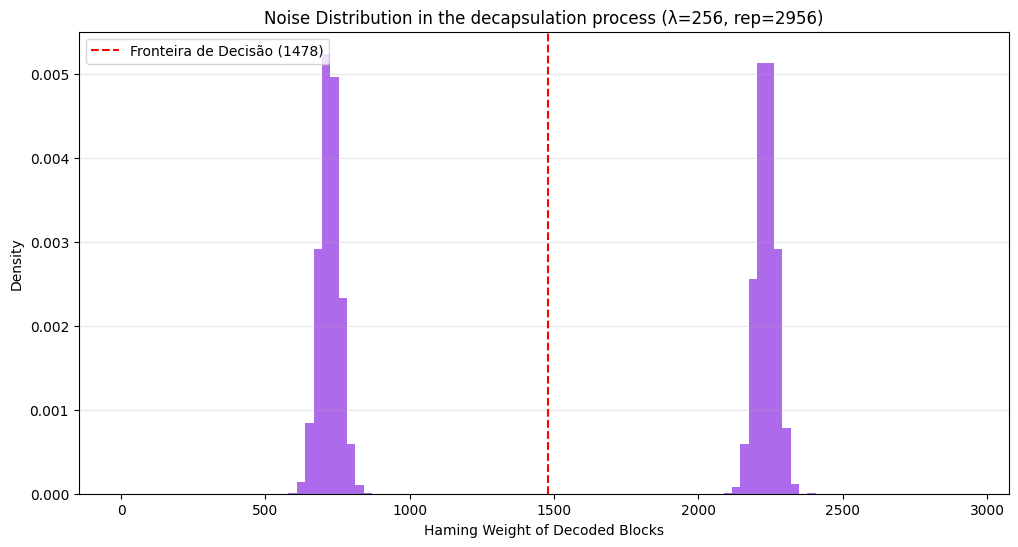

In [23]:
import matplotlib.pyplot as plt
import time
import secrets
import math
import hashlib
import gmpy2

# =============================================================================
# Distribuição de Densidade dos Pesos de Hamming (gmpy2 Otimizado)
# =============================================================================

def repetition_decode_with_weights_gmpy2(c_star_mpz, k, n):
    """Extrai os bits decifrados E os pesos de Hamming observados em cada bloco."""
    rep = n // k
    decoded = 0
    weights = []
    mask = (gmpy2.mpz(1) << rep) - gmpy2.mpz(1)
    
    for i in range(k):
        block = (c_star_mpz >> (i * rep)) & mask
        w = gmpy2.popcount(block)
        weights.append(w)
        if w > (rep // 2):
            decoded |= (1 << i)
    return decoded, weights

def run_simulation_gmpy2(iterations=50, lambda_sec=256, lambda_bit_string_size=256):
    print(f"Iniciando simulação: {iterations} iterações (gmpy2)...")
    t_start = time.time()
    
    pk_sim, sk_sim, n_sim, p_sim, h_sim = generate_keys(lambda_sec)
    rep_size = n_sim // lambda_sec
    all_observed_weights = []
    
    for i in range(iterations):
        # Usando as tuas funções otimizadas existentes
        (C1, C2), K = key_encapsulation(pk_sim, lambda_bit_string_size, n_sim, p_sim, h_sim)
        
        # Decapsulamento (Extração apenas para o gráfico)
        val_to_decode = ((sk_sim * C1) % p_sim) ^ C2
        _, weights = repetition_decode_with_weights_gmpy2(val_to_decode, lambda_bit_string_size, n_sim)
        
        all_observed_weights.extend(weights)
        
        if (i + 1) % 10 == 0:
            print(f"Progresso: {i + 1}/{iterations} ({time.time()-t_start:.1f}s)")

    return all_observed_weights, rep_size

# --- [Execução e Gráfico] ---
L_SEC_PLOT = 256
ITERACOES_PLOT = 50 
L_BIT_STRING_SIZE_PLOT = 256

pesos, rep_size = run_simulation_gmpy2(iterations=ITERACOES_PLOT, lambda_sec=L_SEC_PLOT, lambda_bit_string_size=L_BIT_STRING_SIZE_PLOT)

plt.figure(figsize=(12, 6))
# Dinamicamente ajusta as barras (bins) de acordo com o tamanho da repetição
plt.hist(pesos, bins=range(0, rep_size, max(1, rep_size//100)), density=True, color='blueviolet', alpha=0.7)

# Linha teórica do limite de decisão
plt.axvline(x=rep_size/2, color='red', linestyle='--', label=f'Fronteira de Decisão ({rep_size//2})')

plt.title(f"Noise Distribution in the decapsulation process (λ={L_SEC_PLOT}, rep={rep_size})")
plt.xlabel("Haming Weight of Decoded Blocks")
plt.ylabel("Density")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

#### Given the distance of the code

In [25]:
import secrets
import math
import hashlib

def low_hamming_weight_number(n, h):
    indices = set()
    while len(indices) < h:
        indices.add(secrets.randbelow(n))
    num = 0
    for i in indices:
        num |= (1 << i)
    return num

def repetition_encode_with_rep(m_bits, rep, n):
    k = n // rep
    encoded = 0
    for i in range(k):
        bit = (m_bits >> i) & 1
        if bit:
            mask = ((1 << rep) - 1) << (i * rep)
            encoded |= mask
    return encoded

def repetition_decode_with_rep(c_star, rep, n):
    k = n // rep
    decoded = 0
    for i in range(k):
        block = (c_star >> (i * rep)) & ((1 << rep) - 1)
        if bin(block).count('1') > (rep // 2):
            decoded |= (1 << i)
    return decoded
# --- Core: Geração, Encapsulamento e Decapsulamento ---


def key_encapsulation_with_rep(pk, lambda_param, n, p, h, rep):
    # 1. Pick a uniformly random lambda-bit string K
    K = secrets.randbits(lambda_param)

    # 2. Let A = H1(K), B1 = H2(K), and B2 = H3(K)
    A = H1(K, n, h, lambda_param)
    B1 = H2(K, n, h, lambda_param)
    B2 = H3(K, n, h, lambda_param)
    
    # 3. C1 = A * R + B1; C2 = E(K) XOR (A * T + B2)
    C1 = (A * pk[0] + B1) % p
    encoded_K = repetition_encode_with_rep(K, rep, n)
    # Importante: o XOR ocorre após o mod p do termo (A*T + B2)
    C2 = encoded_K ^ ((A * pk[1] + B2) % p)
    
    return (C1, C2), K

def key_decapsulation_with_rep(C, sk_F, pk, lambda_param, n, p, h, rep):
    # 1. K' = D((F * C1) XOR C2)
    # F * C1 mod p cancela os termos de erro
    dec_val = ((sk_F * C[0]) % p) ^ C[1]
    K_prime = repetition_decode_with_rep(dec_val, rep, n)

    # 2. Re-deriva os parâmetros para verificação (A', B1', B2')
    A_prime = H1(K_prime, n, h, lambda_param)
    B1_prime = H2(K_prime, n, h, lambda_param)
    B2_prime = H3(K_prime, n, h, lambda_param)

    # 3. Reconstrói C' para verificar integridade
    C1_check = (A_prime * pk[0] + B1_prime) % p
    encoded_K_prime = repetition_encode_with_rep(K_prime, rep, n)
    C2_check = encoded_K_prime ^ ((A_prime * pk[1] + B2_prime) % p)

    # 4. Se C' == C, a chave é válida (Segurança IND-CCA)
    if C1_check == C[0] and C2_check == C[1]:
        return K_prime
    return None

# --- Execução do Teste ---

# Configurações
lambda_sec = 256 
rep=2048

lambda_bit_string_size = 16

# 1. Setup (Geração de Chaves)
pk, sk, n, p, h = generate_keys(lambda_sec)
print(f"--- Parâmetros --- \nn: {n}, h: {h}, p: Mersenne Prime")

# 2. Encapsulamento (Criação do Segredo)
(C1, C2), K_original = key_encapsulation_with_rep(pk, lambda_bit_string_size, n, p, h, rep)
print(f"\n--- Encapsulamento --- \nK original: {bin(K_original)}")

# 3. Decapsulamento (Recuperação do Segredo)
K_recuperado = key_decapsulation_with_rep((C1, C2), sk, pk, lambda_bit_string_size, n, p, h, rep)

# 4. Verificação final
if K_recuperado is not None:
    print(f"\n--- Sucesso! --- \nK recuperado: {bin(K_recuperado)}")
    print(f"As chaves coincidem? {K_original == K_recuperado}")
else:
    print("\n--- Erro! --- \nFalha na verificação de integridade.")

--- Parâmetros --- 
n: 756839, h: 256, p: Mersenne Prime

--- Encapsulamento --- 
K original: 0b1011110111000000

--- Sucesso! --- 
K recuperado: 0b1011110111000000
As chaves coincidem? True


Iniciando simulação: 1000 iterações (gmpy2)...
Parâmetros da simulação: n=756839, h=256, p=Mersenne Prime, rep=2048
Progresso: 10/1000 (21.5s)
Progresso: 20/1000 (44.3s)
Progresso: 30/1000 (65.3s)
Progresso: 40/1000 (89.2s)
Progresso: 50/1000 (115.4s)
Progresso: 60/1000 (141.6s)
Progresso: 70/1000 (169.6s)
Progresso: 80/1000 (196.5s)
Progresso: 90/1000 (224.2s)
Progresso: 100/1000 (251.3s)
Progresso: 110/1000 (278.1s)
Progresso: 120/1000 (305.4s)
Progresso: 130/1000 (332.0s)
Progresso: 140/1000 (359.1s)
Progresso: 150/1000 (385.8s)
Progresso: 160/1000 (412.6s)
Progresso: 170/1000 (439.5s)
Progresso: 180/1000 (466.3s)
Progresso: 190/1000 (492.8s)
Progresso: 200/1000 (519.3s)
Progresso: 210/1000 (546.1s)
Progresso: 220/1000 (572.6s)
Progresso: 230/1000 (599.3s)
Progresso: 240/1000 (625.7s)
Progresso: 250/1000 (652.2s)
Progresso: 260/1000 (678.8s)
Progresso: 270/1000 (705.3s)
Progresso: 280/1000 (731.8s)
Progresso: 290/1000 (758.2s)
Progresso: 300/1000 (784.8s)
Progresso: 310/1000 (811.3s

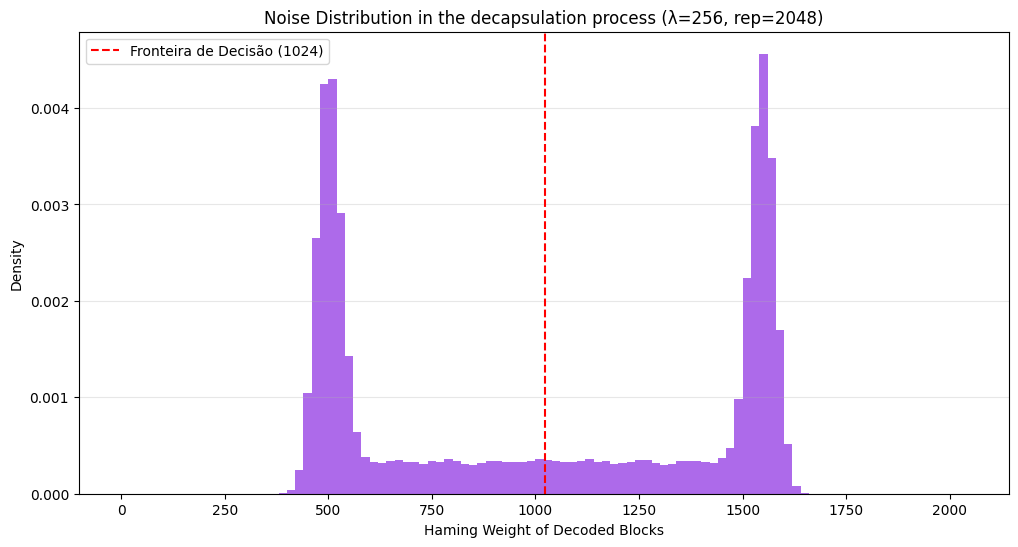

In [29]:
import matplotlib.pyplot as plt
import time
import secrets
import math
import hashlib
import gmpy2

# =============================================================================
# Distribuição de Densidade dos Pesos de Hamming (gmpy2 Otimizado)
# =============================================================================

def repetition_decode_with_weights_gmpy2_with_rep(c_star_mpz, k, n, rep):
    """Extrai os bits decifrados E os pesos de Hamming observados em cada bloco."""
    if (rep * k) > n:
        raise ValueError(f"Total encoded size ({rep * k}) exceeds n ({n}).")

    decoded = 0
    weights = []
    mask = (gmpy2.mpz(1) << rep) - gmpy2.mpz(1)
    
    for i in range(k):
        block = (c_star_mpz >> (i * rep)) & mask
        w = gmpy2.popcount(block)
        weights.append(w)
        if w > (rep // 2):
            decoded |= (1 << i)
    return decoded, weights

def run_simulation_gmpy2(iterations=50, lambda_sec=256, lambda_bit_string_size=256, rep_factor=2048):
    print(f"Iniciando simulação: {iterations} iterações (gmpy2)...")
    t_start = time.time()
    
    pk_sim, sk_sim, n_sim, p_sim, h_sim = generate_keys(lambda_sec)
    print(f"Parâmetros da simulação: n={n_sim}, h={h_sim}, p=Mersenne Prime, rep={rep_factor}")
    all_observed_weights = []

    if (rep_factor * lambda_bit_string_size) > n_sim:
        raise ValueError(f"Total encoded size ({rep_factor * lambda_bit_string_size}) exceeds n ({n_sim}).")
    
    
    for i in range(iterations):
        # Usando as tuas funções otimizadas existentes
        (C1, C2), K = key_encapsulation(pk_sim, lambda_bit_string_size, n_sim, p_sim, h_sim)
        
        # Decapsulamento (Extração apenas para o gráfico)
        val_to_decode = ((sk_sim * C1) % p_sim) ^ C2
        _, weights = repetition_decode_with_weights_gmpy2_with_rep(val_to_decode, lambda_bit_string_size, n_sim, rep_factor)
        
        all_observed_weights.extend(weights)
        
        if (i + 1) % 10 == 0:
            print(f"Progresso: {i + 1}/{iterations} ({time.time()-t_start:.1f}s)")

    return all_observed_weights

# --- [Execução e Gráfico] ---
L_SEC_PLOT = 256
ITERACOES_PLOT = 1000 
L_BIT_STRING_SIZE_PLOT = 256
REP_FACTOR_PLOT = 2048


pesos = run_simulation_gmpy2(iterations=ITERACOES_PLOT, lambda_sec=L_SEC_PLOT, lambda_bit_string_size=L_BIT_STRING_SIZE_PLOT, rep_factor=REP_FACTOR_PLOT)

plt.figure(figsize=(12, 6))
# Dinamicamente ajusta as barras (bins) de acordo com o tamanho da repetição
plt.hist(pesos, bins=range(0, REP_FACTOR_PLOT, max(1, REP_FACTOR_PLOT//100)), density=True, color='blueviolet', alpha=0.7)

# Linha teórica do limite de decisão
plt.axvline(x=REP_FACTOR_PLOT/2, color='red', linestyle='--', label=f'Fronteira de Decisão ({REP_FACTOR_PLOT//2})')

plt.title(f"Noise Distribution in the decapsulation process (λ={L_SEC_PLOT}, rep={REP_FACTOR_PLOT})")
plt.xlabel("Haming Weight of Decoded Blocks")
plt.ylabel("Density")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

#### transform into a publick key cryptosystem using a standard transformation

In [24]:
import secrets
import math
import hashlib

# ==========================================
# --- NOVA CAMADA: Public Key Encryption ---
# ==========================================

def encrypt_pke(pk, message, lambda_param, n, p, h):
    """
    Transformação Padrão: Transforma o KEM num PKE Híbrido.
    Suporta strings ou inteiros.
    """
    # 1. Executa o KEM para obter o texto cifrado da chave e o segredo K
    C_kem, K = key_encapsulation(pk, lambda_param, n, p, h)
    
    # 2. KDF: Deriva a chave simétrica estável usando SHA-256
    K_bytes = int(K).to_bytes((lambda_param + 7) // 8, 'big')
    sym_key = hashlib.sha256(K_bytes).digest()
    
    # Tratamento da mensagem de entrada (texto ou número)
    if isinstance(message, str):
        m_bytes = message.encode('utf-8')
    else:
        m_bytes = message.to_bytes((message.bit_length() + 7) // 8 or 1, 'big')
        
    # 3. Cifra de Fluxo: Expande a chave com SHAKE-256 e faz XOR com a mensagem
    stream = hashlib.shake_256(sym_key).digest(len(m_bytes))
    ciphertext_msg = bytes([b ^ s for b, s in zip(m_bytes, stream)])
    
    # O criptograma final contém o componente KEM e o componente Simétrico
    return C_kem, ciphertext_msg

def decrypt_pke(C_pke, sk_F, pk, lambda_param, n, p, h):
    """
    Decifra o criptograma híbrido recuperando primeiro o KEM.
    """
    C_kem, ciphertext_msg = C_pke
    
    # 1. Recupera o segredo K usando o decapsulamento do KEM
    K = key_decapsulation(C_kem, sk_F, pk, lambda_param, n, p, h)
    
    if K is None:
        raise ValueError("Falha de Integridade: O texto cifrado foi corrompido ou adulterado!")
        
    # 2. Reconstrói a mesma chave simétrica
    K_bytes = int(K).to_bytes((lambda_param + 7) // 8, 'big')
    sym_key = hashlib.sha256(K_bytes).digest()
    
    # 3. Gera o mesmo fluxo pseudoaleatório para reverter o XOR
    stream = hashlib.shake_256(sym_key).digest(len(ciphertext_msg))
    decrypted_bytes = bytes([b ^ s for b, s in zip(ciphertext_msg, stream)])
    
    return decrypted_bytes

# --- Execução do Teste PKE ---

lambda_sec = 256  # Size of the message in bits
lambda_bit_string_size = 256  # Size of the bit string in bits
pk, sk, n, p, h = generate_keys(lambda_sec)

print(f"--- Sistema PKE Híbrido Inicializado (Mersenne n={n}) ---")

# Mensagem Secreta Completa (String)
mensagem_original = "Mensagem ultra secreta pós-quântica baseada em Mersenne!"
print(f"\nMensagem Original: '{mensagem_original}'")

# 1. Encriptação de Chave Pública (PKE)
C_final = encrypt_pke(pk, mensagem_original, lambda_bit_string_size, n, p, h)
print(f"Texto Cifrado Simétrico (hex): {C_final[1].hex()[:30]}...")

# 2. Decifração de Chave Pública (PKE)
dados_recuperados = decrypt_pke(C_final, sk, pk, lambda_bit_string_size, n, p, h)
mensagem_recuperada = dados_recuperados.decode('utf-8')

print(f"\nMensagem Recuperada: '{mensagem_recuperada}'")
print(f"Sucesso Total do PKE? {mensagem_original == mensagem_recuperada}")

--- Sistema PKE Híbrido Inicializado (Mersenne n=756839) ---

Mensagem Original: 'Mensagem ultra secreta pós-quântica baseada em Mersenne!'
Texto Cifrado Simétrico (hex): 0244c6f640c091b591e04b5a545da9...

Mensagem Recuperada: 'Mensagem ultra secreta pós-quântica baseada em Mersenne!'
Sucesso Total do PKE? True


### Encapsulation Method with Reed Muller